In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
import torch
from torch.utils.data import TensorDataset, DataLoader



device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def calculate_rsi(data, period=14):
    #calculate the relative strength index for an array like over [period] days
    #uses pandas
    delta = pd.DataFrame(data).diff()
    loss = delta.copy()
    gains = delta.copy()
    gains[gains < 0] = 0
    loss[loss > 0] = 0
    gain_wm = gains.rolling(period).apply(lambda x: np.sum(np.abs(x))/period)
    loss_wm = loss.rolling(period).apply(lambda x: np.sum(np.abs(x))/period)
    gpl = gain_wm/loss_wm
    return 100-100/(1+gpl)

# Download data, compute features

In [ ]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

syms_array = sp500.sort_values(by='Date added', axis=0)[:50]['Symbol'].values
syms_list = syms_array.tolist()

In [ ]:
train_frac = 0.7
valtest_frac = 0.15


period = 14 #period for technical indicator calculation
prediction_window = 30 #how far ahead to predict directional price movement

train_frames = []
validate_frames = []
test_frames = []

for sym in syms_list:
    tick = yf.Ticker(sym)
    df = tick.history(period='20y', interval='1d')

    if df is None or df.empty:
        print('skipping', sym, 'no data found')
        continue

    if 'Close' not in df.columns or 'High' not in df.columns or 'Low' not in df.columns or 'Volume' not in df.columns:
        print('skipping', sym, 'no close found')
        continue

    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    smooth = close.ewm(alpha=0.8, adjust=False).mean() #exponential smoothing of data

    indicators = pd.DataFrame() #create the dataframe where the indicators will be calculated

    indicators['ret'] = close.pct_change(30)

    #make target columns
    indicators['target'] = (np.sign(close.shift(-prediction_window)-close)>0).astype(int)

    #add symbol column
    indicators['symbol'] = sym

    indicators = indicators.replace([np.inf, -np.inf], np.nan)
    indicators_clean = indicators.dropna()

    train_length = int(len(indicators_clean)*train_frac)
    valtest_length = int(len(indicators_clean)*valtest_frac)



    train = indicators_clean[:train_length]
    validate = indicators_clean[train_length:train_length+valtest_length]
    test = indicators_clean[train_length+valtest_length:]

    

    if train.empty or validate.empty or test.empty:
        print('skipping', sym, 'no clean data')
        continue

    train_frames.append(train)
    validate_frames.append(validate)
    test_frames.append(test)

train_indicators = pd.concat(train_frames)
validate_indicators = pd.concat(validate_frames)
test_indicators = pd.concat(test_frames)

print('dataset size:', train_indicators.shape+validate_indicators.shape+test_indicators.shape)

dataset size: (176000, 3, 37700, 3, 37750, 3)


In [91]:
train_frac = 0.7
valtest_frac = 0.15


period = 14 #period for technical indicator calculation
prediction_window = 30 #how far ahead to predict directional price movement

train_frames = []
validate_frames = []
test_frames = []

for sym in syms_list:
    tick = yf.Ticker(sym)
    df = tick.history(period='20y', interval='1d')

    if df is None or df.empty:
        print('skipping', sym, 'no data found')
        continue

    if 'Close' not in df.columns or 'High' not in df.columns or 'Low' not in df.columns or 'Volume' not in df.columns:
        print('skipping', sym, 'no close found')
        continue

    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    smooth = close.ewm(alpha=0.8, adjust=False).mean() #exponential smoothing of data

    indicators = pd.DataFrame() #create the dataframe where the indicators will be calculated

    #simple movingv average
    indicators['sma'] = smooth.rolling(period).mean()

    #stochastic K%
    indicators['stck'] = (smooth - low.rolling(period).min()) / (high.rolling(period).max() - low.rolling(period).min()) * 100

    #stochastic D% 
    indicators['stcd'] = indicators['stck'].rolling(3).sum()/3

    #momentum 
    indicators['mom'] = smooth.diff(period-1)

    #relative strength index
    indicators['rsi'] = calculate_rsi(smooth)

    #moving average convergence divergence
    emas = smooth.ewm(span = 12, adjust=False).mean() - smooth.ewm(span=26, adjust=False).mean()
    indicators['macd'] = emas

    #williams R%
    indicators['lwr'] = -100 * (high.rolling(period).max() - smooth) / (high.rolling(period).max() - low.rolling(period).min())

    #rate of change
    indicators['roc'] = 100 * smooth.diff(period)/smooth.shift(period)

    #Accumulation Distribution Oscillator
    indicators['ado'] = (high-smooth.shift(1))/(high-low) 

    #Commodity Channel Index
    tp = (smooth+high+low)/3
    stp = tp.rolling(period).sum() / period
    d = tp.rolling(period).apply(lambda x: np.mean(np.abs(x-x.mean())))
    indicators['cci'] = (tp-stp)/(0.015*d)

    #on balance volume
    indicators['obv'] = (np.sign(smooth.diff()) * volume).fillna(0).cumsum().pct_change()

    #make target columns
    indicators['target'] = (np.sign(close.shift(-prediction_window)-close)>0).astype(int)

    #add symbol column
    indicators['symbol'] = sym

    indicators = indicators.replace([np.inf, -np.inf], np.nan)
    indicators_clean = indicators.dropna()

    train_length = int(len(indicators_clean)*train_frac)
    valtest_length = int(len(indicators_clean)*valtest_frac)

    indicators_clean['stck'] /= np.nanmax(indicators_clean['stck'][:train_length].abs())
    indicators_clean['stcd'] /= np.nanmax(indicators_clean['stcd'][:train_length].abs())
    indicators_clean['lwr'] /= np.nanmax(indicators_clean['lwr'][:train_length].abs())
    indicators_clean['macd'] /= np.nanmax(indicators_clean['macd'][:train_length].abs())
    indicators_clean['roc'] /= np.nanmax(indicators_clean['roc'][:train_length].abs())
    indicators_clean['rsi'] /= np.nanmax(indicators_clean['rsi'][:train_length].abs())
    indicators_clean['sma'] /= np.nanmax(indicators_clean['sma'][:train_length].abs())
    indicators_clean['mom'] /= np.nanmax(indicators_clean['mom'][:train_length].abs())
    indicators_clean['ado'] /= np.nanmax(indicators_clean['ado'][:train_length].abs())
    indicators_clean['cci'] /= np.nanmax(indicators_clean['cci'][:train_length].abs())

    train = indicators_clean[:train_length]
    validate = indicators_clean[train_length:train_length+valtest_length]
    test = indicators_clean[train_length+valtest_length:]

    

    if train.empty or validate.empty or test.empty:
        print('skipping', sym, 'no clean data')
        continue

    train_frames.append(train)
    validate_frames.append(validate)
    test_frames.append(test)

train_indicators = pd.concat(train_frames)
validate_indicators = pd.concat(validate_frames)
test_indicators = pd.concat(test_frames)

print('dataset size:', train_indicators.shape+validate_indicators.shape+test_indicators.shape)

dataset size: (175498, 13, 37600, 13, 37650, 13)


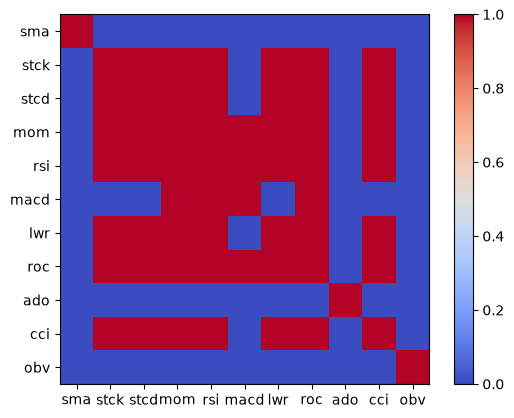

In [ ]:
plt.imshow(train_indicators.drop(columns=['symbol','target']).corr()>0.6, cmap='coolwarm')
plt.xticks(ticks=np.arange(11), labels=train_indicators.drop(columns=['symbol', 'target']).columns)
plt.yticks(ticks=np.arange(11), labels=train_indicators.drop(columns=['symbol', 'target']).columns)
plt.colorbar()
plt.show()

# Create windows, train/val/test/split, pytorch data sets

In [92]:
window_size=30

Xtrain_list=[]
ytrain_list=[]

Xvalidate_list=[]
yvalidate_list=[]

Xtest_list=[]
ytest_list=[]

for sym in syms_list:
    train = train_indicators[train_indicators['symbol']==sym].sort_index()
    validate = validate_indicators[validate_indicators['symbol']==sym].sort_index()
    test = test_indicators[test_indicators['symbol']==sym].sort_index()

    indicators = (train.drop(columns=['target', 'symbol', 'obv', 'stcd', 'mom', 'rsi', 'roc']).values, 
                  validate.drop(columns=['target', 'symbol', 'obv', 'stcd', 'mom', 'rsi', 'roc']).values, 
                  test.drop(columns=['target', 'symbol', 'obv', 'stcd', 'mom', 'rsi', 'roc']).values)
    
    target = (train['target'].values, 
              validate['target'].values, 
              test['target'].values)
    
    for i in range(window_size,len(train[:-window_size])):
        Xtrain_list.append(indicators[0][i-window_size:i])
        ytrain_list.append(target[0][i-1])

    for i in range(window_size, len(validate[window_size:-window_size])):
        Xvalidate_list.append(indicators[1][i-window_size:i])
        yvalidate_list.append(target[1][i-1])

    for i in range(window_size, len(test[window_size:])):
        Xtest_list.append(indicators[2][i-window_size:i])
        ytest_list.append(target[2][i-1])



Xtrain=np.array(Xtrain_list,dtype=np.float32)
ytrain=np.array(ytrain_list,dtype=np.float32)
Xvalidate=np.array(Xvalidate_list,dtype=np.float32)
yvalidate=np.array(yvalidate_list,dtype=np.float32)
Xtest=np.array(Xtest_list,dtype=np.float32)
ytest=np.array(ytest_list,dtype=np.float32)

Xtrain.shape, ytrain.shape, Xvalidate.shape, yvalidate.shape, Xtest.shape, ytest.shape

((172498, 30, 6),
 (172498,),
 (33100, 30, 6),
 (33100,),
 (34650, 30, 6),
 (34650,))

In [93]:
batch_size = 64
Xtrain_t=torch.tensor(Xtrain)
ytrain_t=torch.tensor(ytrain.reshape(-1,1))
Xval_t=torch.tensor(Xvalidate)
yvalidate_t=torch.tensor(yvalidate.reshape(-1,1))
Xtest_t=torch.tensor(Xtest)
ytest_t=torch.tensor(ytest.reshape(-1,1))

train_loader=DataLoader(TensorDataset(Xtrain_t,ytrain_t),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TensorDataset(Xval_t,yvalidate_t),batch_size=batch_size)
test_loader=DataLoader(TensorDataset(Xtest_t,ytest_t),batch_size=batch_size)

# Define model and evaluation functions

In [94]:
class LSTMClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm=nn.LSTM(feature_dim,hidden_size,num_layers,batch_first=True)
        self.fc=nn.Linear(hidden_size,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,x):
        out,_=self.lstm(x.float())
        out=self.fc(out[:,-1,:])
        return self.sigmoid(out)
    
def train_epoch(model,loader,crit,opt):
    model.train(); total=correct=loss_sum=0
    for xb,yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred=model(xb)
        loss=crit(pred,yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        loss_sum+=loss.item()*len(xb)
        correct+=((pred>=0.5).float()==yb).sum().item()
        total+=len(xb)
    return loss_sum/total, correct/total

def eval_epoch(model,loader,crit):
    model.eval(); total=correct=loss_sum=0; preds=[]; labels=[]
    with torch.no_grad():
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            pred=model(xb)
            loss=crit(pred,yb)
            loss_sum+=loss.item()*len(xb)
            correct+=((pred>=0.5).float()==yb).sum().item()
            total+=len(xb)
            preds.extend((pred>=0.5).cpu().numpy().astype(int))
            labels.extend(yb.cpu().numpy().astype(int))
    return loss_sum/total, correct/total, preds, labels

In [95]:
Xtrain_seq=Xtrain.reshape(-1, window_size, 6)
Xval_seq=Xvalidate.reshape(-1, window_size, 6)
Xtest_seq=Xtest.reshape(-1, window_size, 6)

train_loader_seq=DataLoader(TensorDataset(torch.tensor(Xtrain_seq),ytrain_t),batch_size=batch_size,shuffle=True)
val_loader_seq=DataLoader(TensorDataset(torch.tensor(Xval_seq),yvalidate_t),batch_size=batch_size)
test_loader_seq=DataLoader(TensorDataset(torch.tensor(Xtest_seq),ytest_t),batch_size=batch_size)

In [100]:
lstm=LSTMClassifier(feature_dim=6).to(device)
opt2=torch.optim.Adam(lstm.parameters(), lr=1e-6)
best_l=None; best_val_l=float("inf")
crit=nn.BCELoss()


for epoch in range(1,6):
    tr_l,tr_a=train_epoch(lstm,train_loader_seq,crit,opt2)
    va_l,va_a,_,_=eval_epoch(lstm,val_loader_seq,crit)
    print(f"LSTM {epoch}: Train {tr_l:.4f}/{tr_a:.4f}, Val {va_l:.4f}/{va_a:.4f}")
    if va_l<best_val_l: 
        best_val_l=va_l
        best_l=lstm.state_dict()

lstm.load_state_dict(best_l)

LSTM 1: Train 0.6845/0.5977, Val 0.6866/0.5679
LSTM 2: Train 0.6823/0.5977, Val 0.6855/0.5679
LSTM 3: Train 0.6805/0.5977, Val 0.6846/0.5679
LSTM 4: Train 0.6789/0.5977, Val 0.6841/0.5679
LSTM 5: Train 0.6775/0.5977, Val 0.6837/0.5679


<All keys matched successfully>

In [101]:
tl,ta,preds,labels=eval_epoch(lstm,test_loader_seq,crit)
print("LSTM Test Accuracy:", ta)

LSTM Test Accuracy: 0.5844155844155844


In [115]:
opt = yf.Ticker('AAPL').option_chain()